# Imports and Settings

In [7]:
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import pickle

# Select treshhold function

In [2]:
def select_threshold_by_tpr(
    y_true: np.ndarray, 
    y_proba: np.ndarray, 
    desired_tpr: float = 0.8
) -> Tuple[float, float, float]:
    """
    Подбирает порог классификации по заданному уровню полноты (True Positive Rate).

    Args:
        y_true : Истинные бинарные метки классов (0 или 1), shape (n_samples,).
        y_proba : Предсказанные вероятности положительного класса, shape (n_samples,).
        desired_tpr : Желаемый уровень TPR. По умолчанию 0.8.

    Returns:
        Tuple[float, float, float]: Кортеж из трех элементов:
            - threshold (float): Порог классификации, при котором TPR >= desired_tpr.
            - tpr (float): Достигнутый уровень TPR при этом пороге.
            - fpr (float): Частота ложноположительных срабатываний (FPR) при этом пороге.
    """
    # Вычисляем значения всех возможных порогов и FPR, TPR при них 
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    # Находим индексы, где TPR >= desired_tpr
    candidates = np.where(tpr >= desired_tpr)[0]

    # Если желаемый TPR недостижим, выбираем индекс с максимальным TPR
    if len(candidates) == 0:
        idx = np.argmax(tpr)
            
    # Иначе берем минимальный порог, при котором TPR >= desired_tpr
    else:
        idx = candidates[0]

    # Возвращаем выбранный порог, TPR и FPR при этом пороге
    return thresholds[idx], tpr[idx], fpr[idx]

# Roc_curve

Для построения ROC кривой будем использовать консервативную схему поиска ГП (ноутбук hyperparameter_tuning_with_optuna) 
как более надёжную.
Классическая и агрессивная схема показали почти одинаковые результаты на тестовой выборке (0.75723, 0.75719) 

In [3]:
df_test = pd.read_csv('../data/processed/cut_corr_imp_test.csv')
df_test.shape

(600000, 61)

In [4]:
X_test = df_test.drop(['id', 'flag'], axis=1)
y_test = df_test.flag
X_test.shape, y_test.shape

((600000, 59), (600000,))

In [5]:
# Загружаем веса моделей - их AUC на валидации
with open('../models/сonservative_models_weights.pkl', 'rb') as f:
    state = pickle.load(f)
 
val_auc_list = state['val_auc_list']
val_auc_list

[0.7576036850511159,
 0.7554545982995526,
 0.7532810994057619,
 0.7546988571803108,
 0.7524269260453276,
 0.7546930331964138]

In [8]:
# Соберём словарь с моделями и их метриками
models_dict = {}
for i in range(5):
    model = CatBoostClassifier()
    model.load_model(f'../models/fold_{i}_сonservative_model.bin')
    models_dict[f'fold_{i}_model'] = (model, val_auc_list[i])

model = CatBoostClassifier()
model.load_model('../models/full_data_сonservative_model.bin')
models_dict['full_data_model'] = (model, val_auc_list[5])
models_dict

{'fold_0_model': (<catboost.core.CatBoostClassifier at 0x14a608800>,
  0.7576036850511159),
 'fold_1_model': (<catboost.core.CatBoostClassifier at 0x10ecda870>,
  0.7554545982995526),
 'fold_2_model': (<catboost.core.CatBoostClassifier at 0x14a572de0>,
  0.7532810994057619),
 'fold_3_model': (<catboost.core.CatBoostClassifier at 0x14a572870>,
  0.7546988571803108),
 'fold_4_model': (<catboost.core.CatBoostClassifier at 0x149ce0cb0>,
  0.7524269260453276),
 'full_data_model': (<catboost.core.CatBoostClassifier at 0x14a20bce0>,
  0.7546930331964138)}

In [9]:
"""
Собираем средневзвешенный по AUC предикт вероятностей классов 
на всех моделях фолдов и финальной моделе.
"""

df_pred = pd.DataFrame()

# Для каждой модели из словаря models_dict
for model_name, value in models_dict.items():
    # Получаем вероятности положительного класса на тестовой выборке
    pred = value[0].predict_proba(X_test)[:, 1]
    # Умножаем предсказания на вес модели (AUC на валидации или средний AUC)
    pred_coef = pred * value[1]
    # Сохраняем взвешенные предсказания в DataFrame
    df_pred[model_name] = pred_coef

# Суммируем веса всех моделей
weights_sum = sum(val[1] for val in models_dict.values())
# Формируем итоговое взвешенное среднее предсказание ансамбля
df_pred['ensemble_weighted_pred'] = df_pred.sum(axis=1) / weights_sum
# Получаем AUC ансамбля на тесте
auc = roc_auc_score(y_test, df_pred['ensemble_weighted_pred'])
print('AUC ensemble weighted test', auc)  

AUC ensemble weighted test 0.7572337893426191


In [10]:
df_pred

,fold_0_model,fold_1_model,fold_2_model,fold_3_model,fold_4_model,full_data_model,ensemble_weighted_pred
0,0.311332,0.281306,0.310687,0.301043,0.305799,0.303800,0.400597
1,0.458813,0.443951,0.440193,0.428172,0.433123,0.412836,0.577959
2,0.371575,0.391391,0.378054,0.363470,0.374276,0.366214,0.495782
3,0.247007,0.236710,0.237670,0.256054,0.209763,0.196154,0.305501
4,0.386261,0.399735,0.365984,0.399634,0.373339,0.402774,0.514056
...,...,...,...,...,...,...,...
599995,0.356894,0.385319,0.378197,0.378471,0.371458,0.388989,0.498951
599996,0.218918,0.196052,0.229173,0.215380,0.231841,0.214060,0.288290
599997,0.075869,0.084478,0.072349,0.063650,0.079298,0.080528,0.100741
599998,0.436347,0.415625,0.415014,0.430303,0.445256,0.422070,0.566371


Итоговые предсказанные вероятности не выглядят как простое среднее по предсказаниям моделей, потому что предсказания умножаются на веса моделей (примерно 0.75), что уменьшает их значения. Однако деление суммы взвешенных предсказаний на сумму весов восстанавливает правильный масштаб  итоговых вероятностей.

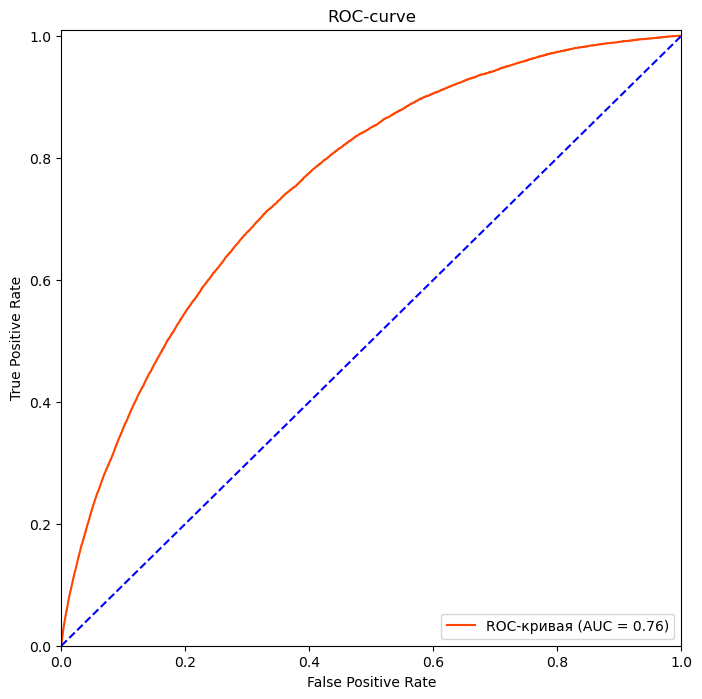

In [11]:
"""
Для каждого возможного порога классификации вычислим значения 
False Positive Rate (доля отрицательных примеров, ошибочно классифицированных как положительные)
True Positive Rate (доля истинноположительных среди всех положительных)
и соответствующие пороги.
"""
fpr, tpr, thresholds = roc_curve(y_test, df_pred['ensemble_weighted_pred'])

plt.figure(figsize=(8, 8))

# Построим график ROC-curve
plt.plot(
    fpr,
    tpr,
    color='orangered',
    label=f'ROC-кривая (AUC = {auc:.2f})'
)
# Добавим центральная диагональная линию для наглядности
plt.plot(
    [0, 1],
    [0, 1],
    color='blue',
    linestyle='--'
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.show()

# Optimal Thresholds selection

Найдём лучший порог классификации при котором разница между    
TPR и FPR будет максимальна.    
Эта разница отражает, насколько модель хорошо отделяет    
положительные примеры от отрицательных при данном пороге.   

In [12]:
y_proba = df_pred['ensemble_weighted_pred']
y_proba.shape

(600000,)

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [14]:
# Находим индекс, при котором разница между TPR и FPR максимальна
optimal_idx = (tpr - fpr).argmax()

# Используем этот индекс, чтобы получить оптимальный порог из массива thresholds
optimal_threshold = thresholds[optimal_idx]

# Выводим лучший порог с точностью до 4 знаков после запятой
print(f'Лучший порог: {optimal_threshold:.5f}')

# Выводим значения TPR и FPR для найденного оптимального порога с точностью до 3 знаков после запятой
print(f'TPR: {tpr[optimal_idx]:.3f}, FPR: {fpr[optimal_idx]:.3f}')

Лучший порог: 0.49642
TPR: 0.712, FPR: 0.330


In [15]:
# Посмотрим на точность ансамбля и матрицу ошибок при СТАНДАРТНОМ пороге
pred = (y_proba >= 0.5).astype(int)
print('accuracy_score', accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize='true')

accuracy_score 0.6760566666666666


array([[0.67495576, 0.32504424],
       [0.29401541, 0.70598459]])

In [16]:
# Посмотрим на точность ансамбля и матрицу ошибок при НАЙДЕННОМ пороге
pred = (y_proba >= optimal_threshold).astype(int)
print('accuracy_score', accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize='true')

accuracy_score 0.6713016666666667


array([[0.66982022, 0.33017978],
       [0.2884254 , 0.7115746 ]])

Разница небольшая.
В классификаторе пайплайна для предикта будем пользоваться найденным порогом.     
Но в кредитном скоринге важно контролировать полноту (TPR) по дефолтным клиентам, чтобы не пропустить слишком много рисковых заемщиков.
При этом нужно учитывать, что повышение TPR обычно ведёт к росту FPR — ложноположительных решений (отказов надёжным клиентам).    
И хотя такой задачи не ставилось, создадим механизм для нахождения порога классификатора по заданному значению полноты.    
Подбор порога по TPR позволяет задать бизнес-ограничения и найти компромисс между рисками и упущенной прибылью.  

In [17]:
# Выберем TPR = 0.85
threshold, tpr_val, fpr_val = select_threshold_by_tpr(y_test, y_proba, desired_tpr=0.85)
print(f"Выбранный порог: {threshold:.4f}, TPR: {tpr_val:.3f}, FPR: {fpr_val:.3f}")

Выбранный порог: 0.3840, TPR: 0.850, FPR: 0.500


In [18]:
# Посмотрим на точность ансамбля и матрицу ошибок при НАЙДЕННОМ пороге
pred = (y_proba >= threshold).astype(int)
print('accuracy_score', accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize='true')

accuracy_score 0.5125933333333333


array([[0.50018144, 0.49981856],
       [0.14999061, 0.85000939]])

Точность упала и FPR выросла, но это ожидаемый результат так как представителей класса 0 в дастасете в 27 раз больше и 
и занижение порога в пользу класса 1 естественно понижает общую точность предсказаний модели.